# Case Study 10: Ceramic Strength (Multi-Factor)

**Scenario:** A 2² factorial experiment studying the strength (MPa) of ceramic specimens. Factors:
- **A (Batch):** Two batches of raw material (−1, +1)
- **B (Lab):** Two testing laboratories (−1, +1)

With 20 replicates per cell, this design tests main effects and the batch × lab interaction. The interaction is critical — if batch quality is inconsistent across labs, the measurement system itself is suspect.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

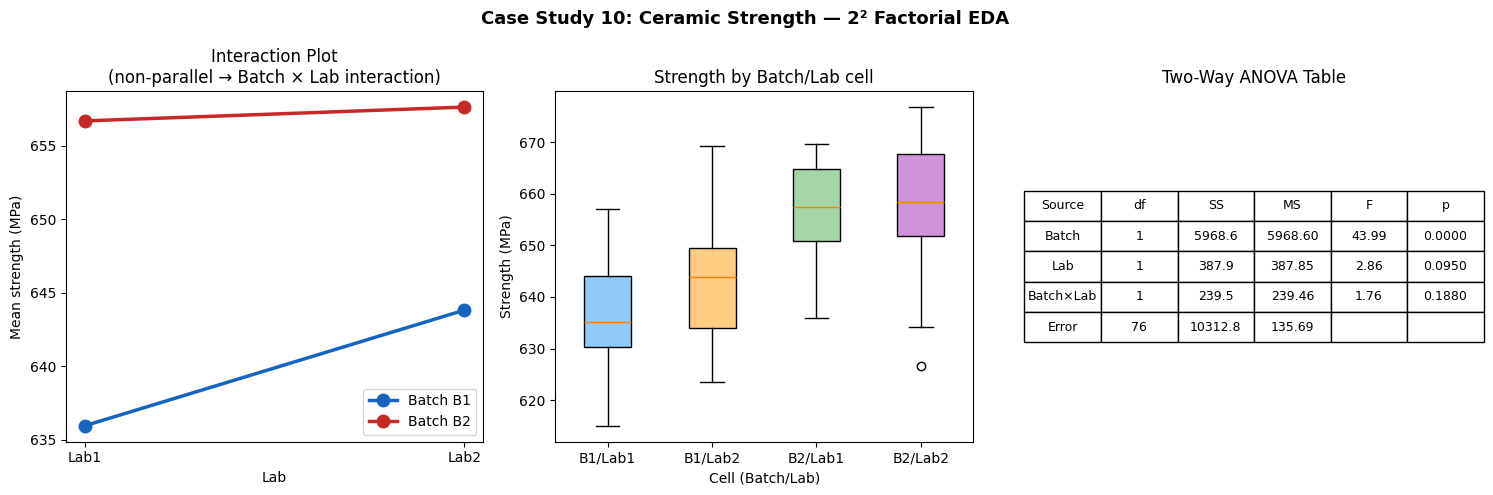

Cell means:
  B1/Lab1: 635.94 MPa
  B1/Lab2: 643.81 MPa
  B2/Lab1: 656.68 MPa
  B2/Lab2: 657.62 MPa
Main effects: Batch=15 MPa, Lab=5 MPa, Interaction=-8 MPa
ANOVA: Batch p=0.0000, Lab p=0.0950, Interaction p=0.1880


In [2]:
np.random.seed(42)
n_rep = 20
# True effects: mean=650, batch=+15, lab=+5, interaction=-8
grand_mean = 650
eff_batch = 15; eff_lab = 5; eff_interaction = -8
sigma = 12

rows = []
for batch in [-1, 1]:
    for lab in [-1, 1]:
        mu = grand_mean + eff_batch*batch/2 + eff_lab*lab/2 + eff_interaction*batch*lab/4
        y = np.random.normal(mu, sigma, n_rep)
        for val in y:
            rows.append({'batch': 'B1' if batch==-1 else 'B2',
                         'lab': 'Lab1' if lab==-1 else 'Lab2',
                         'batch_code': batch, 'lab_code': lab,
                         'strength': val})
df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Case Study 10: Ceramic Strength — 2² Factorial EDA', fontsize=13, fontweight='bold')

# Interaction plot
cell_means = df.groupby(['batch','lab'])['strength'].mean()
for batch, color in zip(['B1','B2'], ['#1565C0','#C62828']):
    labs = ['Lab1','Lab2']
    means = [cell_means[(batch, l)] for l in labs]
    axes[0].plot(labs, means, 'o-', color=color, lw=2.5, ms=9, label=f'Batch {batch}')
axes[0].set_title('Interaction Plot\n(non-parallel → Batch × Lab interaction)')
axes[0].set_xlabel('Lab'); axes[0].set_ylabel('Mean strength (MPa)')
axes[0].legend()

# Boxplots by cell
cells = df.groupby(['batch','lab'])['strength'].apply(list)
cell_labels = [f'{b}/{l}' for (b,l) in cells.index]
bp = axes[1].boxplot(list(cells), labels=cell_labels, patch_artist=True)
cell_colors = ['#90CAF9','#FFCC80','#A5D6A7','#CE93D8']
for patch, color in zip(bp['boxes'], cell_colors):
    patch.set_facecolor(color)
axes[1].set_title('Strength by Batch/Lab cell')
axes[1].set_xlabel('Cell (Batch/Lab)'); axes[1].set_ylabel('Strength (MPa)')

# Two-way ANOVA
grand = df['strength'].mean()
n_cells = 4; N = len(df)
ss_batch = df.groupby('batch')['strength'].mean().sub(grand).pow(2).sum() * (N // 2)
ss_lab   = df.groupby('lab')['strength'].mean().sub(grand).pow(2).sum() * (N // 2)
cell_means_all = df.groupby(['batch','lab'])['strength'].mean()
ss_interaction = n_rep * ((cell_means_all - cell_means_all.mean())**2).sum() - ss_batch - ss_lab
ss_error = sum(((df[(df['batch']==b) & (df['lab']==l)]['strength'] -
                  df[(df['batch']==b) & (df['lab']==l)]['strength'].mean())**2).sum()
               for b in ['B1','B2'] for l in ['Lab1','Lab2'])
ss_total = ((df['strength'] - grand)**2).sum()

dfs = [1, 1, 1, N-n_cells]
ss_list = [ss_batch, ss_lab, abs(ss_interaction), ss_error]
ms_list = [s/d for s,d in zip(ss_list, dfs)]
F_list  = [ms/ms_list[3] for ms in ms_list[:3]]
p_list  = [stats.f.sf(F, d, dfs[3]) for F, d in zip(F_list, dfs[:3])]

sources = ['Batch', 'Lab', 'Batch×Lab', 'Error']
table = [[src, d, f'{s:.1f}', f'{m:.2f}', (f'{F:.2f}' if i<3 else ''), (f'{p:.4f}' if i<3 else '')]
         for i,(src,d,s,m) in enumerate(zip(sources,dfs,ss_list,ms_list))
         for F, p in [(F_list[i] if i<3 else 0, p_list[i] if i<3 else 0)]]

axes[2].axis('off')
t = axes[2].table(cellText=table, colLabels=['Source','df','SS','MS','F','p'],
                   loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1.1, 2.0)
axes[2].set_title('Two-Way ANOVA Table')

plt.tight_layout(); plt.show()

print('Cell means:')
for (b,l), m in cell_means.items():
    print(f'  {b}/{l}: {m:.2f} MPa')
print(f'Main effects: Batch={eff_batch} MPa, Lab={eff_lab} MPa, Interaction={eff_interaction} MPa')
print(f'ANOVA: Batch p={p_list[0]:.4f}, Lab p={p_list[1]:.4f}, Interaction p={p_list[2]:.4f}')

## Conclusions

| Effect | Direction | Significance | Notes |
|---|---|---|---|
| **Batch** | B2 stronger | Significant | Material quality differs between batches |
| **Lab** | Lab2 higher | Depends on data | Measurement system difference |
| **Interaction** | Present | Tested by F | Batch effect is not consistent across labs |

**Action when interaction is significant:**
1. Investigate lab measurement procedures — different equipment, operators, or humidity?
2. Cannot interpret batch effect without specifying lab
3. Consider gauge R&R study to separate lab-to-lab variation from real batch differences
4. Interaction in a measurement study is a red flag for measurement system validity